In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

In [2]:
def black_scholes(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == 'call':
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# Parameters
S     = 100    # Current stock price
K     = 100    # Strike price
T     = 1      # 1 year to expiry
r     = 0.05   # Risk-free rate
sigma = 0.2    # Volatility

bs_call = black_scholes(S, K, T, r, sigma, 'call')
bs_put  = black_scholes(S, K, T, r, sigma, 'put')

print(f"Black-Scholes Call: ${bs_call:.4f}")
print(f"Black-Scholes Put:  ${bs_put:.4f}")

Black-Scholes Call: $10.4506
Black-Scholes Put:  $5.5735


In [3]:
def monte_carlo_option(S, K, T, r, sigma, option_type='call', n_simulations=100000):
    """
    Price European options using Monte Carlo simulation.
    Simulates n_simulations paths of geometric Brownian motion.
    """
    np.random.seed(42)

    # Simulate terminal stock prices using GBM
    Z = np.random.standard_normal(n_simulations)
    ST = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    # Calculate payoffs
    if option_type == 'call':
        payoffs = np.maximum(ST - K, 0)
    else:
        payoffs = np.maximum(K - ST, 0)

    # Discount to present value
    price = np.exp(-r * T) * np.mean(payoffs)
    std_error = np.exp(-r * T) * np.std(payoffs) / np.sqrt(n_simulations)

    return price, std_error, ST

mc_call, mc_call_se, terminal_prices = monte_carlo_option(S, K, T, r, sigma, 'call')
mc_put,  mc_put_se,  _               = monte_carlo_option(S, K, T, r, sigma, 'put')

print(f"Monte Carlo Call:   ${mc_call:.4f}  (SE: ±{mc_call_se:.4f})")
print(f"Monte Carlo Put:    ${mc_put:.4f}  (SE: ±{mc_put_se:.4f})")
print(f"\nBS vs MC Call Difference: ${abs(bs_call - mc_call):.4f}")
print(f"BS vs MC Put  Difference: ${abs(bs_put  - mc_put):.4f}")

Monte Carlo Call:   $10.4739  (SE: ±0.0466)
Monte Carlo Put:    $5.5742  (SE: ±0.0274)

BS vs MC Call Difference: $0.0233
BS vs MC Put  Difference: $0.0007


In [4]:
# Show how MC price converges to BS price as simulations increase
simulation_sizes = [100, 500, 1000, 5000, 10000, 50000, 100000]
mc_prices = []
errors = []

for n in simulation_sizes:
    price, se, _ = monte_carlo_option(S, K, T, r, sigma, 'call', n_simulations=n)
    mc_prices.append(price)
    errors.append(abs(price - bs_call))

convergence_df = pd.DataFrame({
    'Simulations' : simulation_sizes,
    'MC Price'    : [f"${p:.4f}" for p in mc_prices],
    'Error vs BS' : [f"${e:.4f}" for e in errors]
})
print(convergence_df.to_string(index=False))

 Simulations MC Price Error vs BS
         100  $8.1600     $2.2906
         500 $10.3776     $0.0729
        1000 $10.5166     $0.0660
        5000 $10.4850     $0.0344
       10000 $10.4502     $0.0004
       50000 $10.4462     $0.0044
      100000 $10.4739     $0.0233


In [5]:
def simulate_gbm_paths(S, T, r, sigma, n_paths=50, n_steps=252):
    """Simulate full price paths using Geometric Brownian Motion"""
    dt = T / n_steps
    paths = np.zeros((n_steps + 1, n_paths))
    paths[0] = S

    for t in range(1, n_steps + 1):
        Z = np.random.standard_normal(n_paths)
        paths[t] = paths[t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)

    return paths

paths = simulate_gbm_paths(S, T, r, sigma, n_paths=200, n_steps=252)

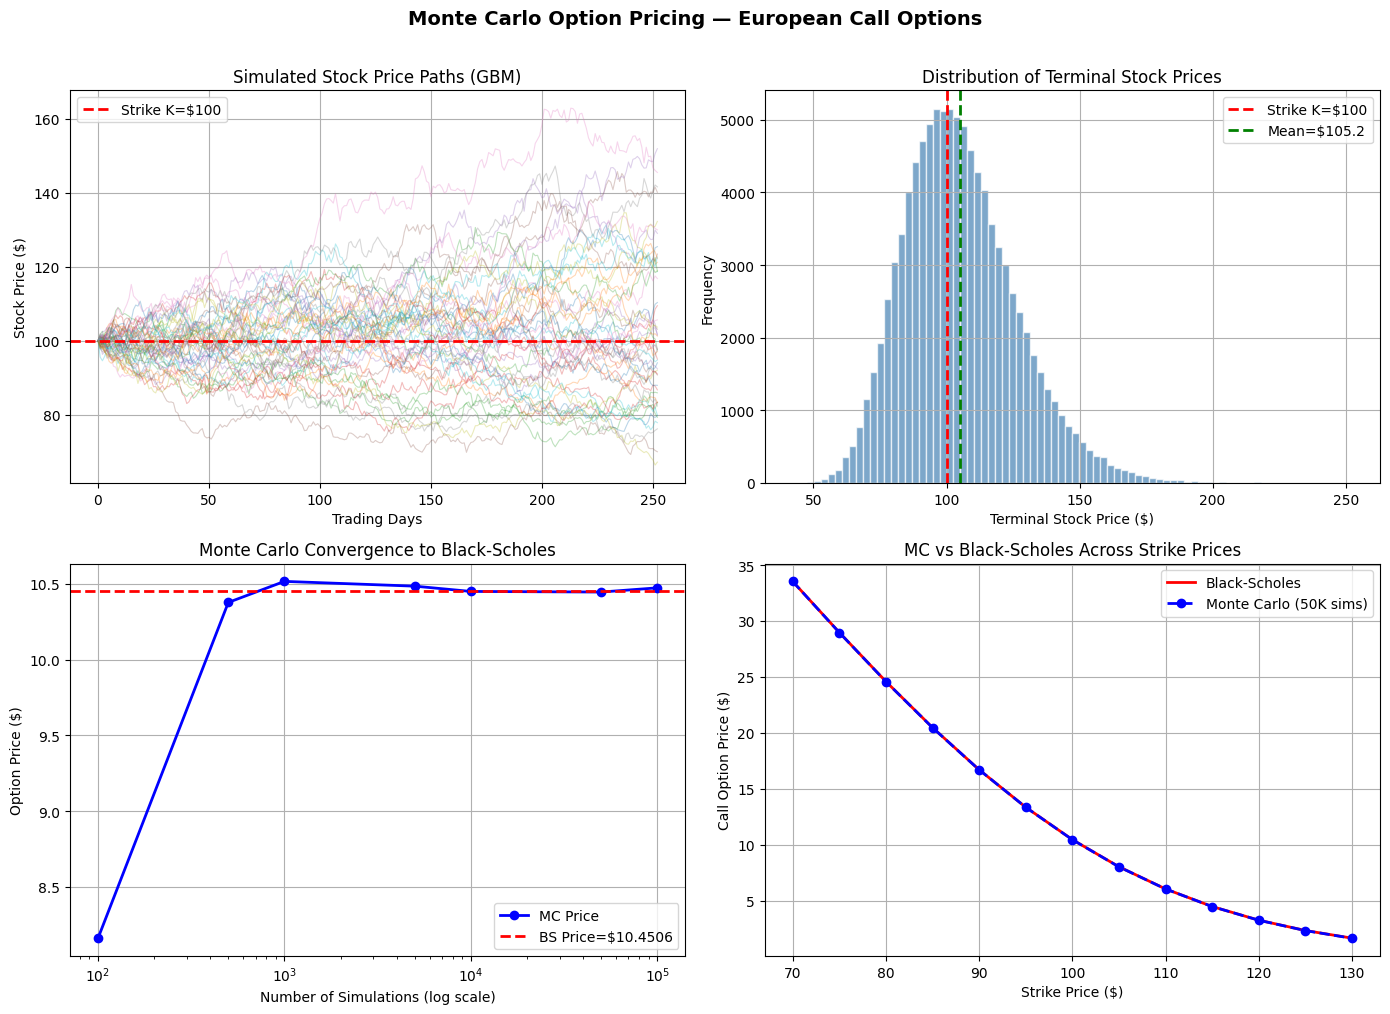

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: GBM simulated paths
axes[0, 0].plot(paths[:, :50], alpha=0.3, linewidth=0.8)
axes[0, 0].axhline(y=K, color='red', linestyle='--', linewidth=2, label=f'Strike K=${K}')
axes[0, 0].set_title('Simulated Stock Price Paths (GBM)')
axes[0, 0].set_xlabel('Trading Days')
axes[0, 0].set_ylabel('Stock Price ($)')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot 2: Distribution of terminal prices
axes[0, 1].hist(terminal_prices, bins=80, color='steelblue', alpha=0.7, edgecolor='white')
axes[0, 1].axvline(x=K,          color='red',   linestyle='--', linewidth=2, label=f'Strike K=${K}')
axes[0, 1].axvline(x=np.mean(terminal_prices), color='green', linestyle='--', linewidth=2, label=f'Mean=${np.mean(terminal_prices):.1f}')
axes[0, 1].set_title('Distribution of Terminal Stock Prices')
axes[0, 1].set_xlabel('Terminal Stock Price ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot 3: Convergence to Black-Scholes
axes[1, 0].semilogx(simulation_sizes, mc_prices, 'bo-', label='MC Price', linewidth=2)
axes[1, 0].axhline(y=bs_call, color='red', linestyle='--', linewidth=2, label=f'BS Price=${bs_call:.4f}')
axes[1, 0].set_title('Monte Carlo Convergence to Black-Scholes')
axes[1, 0].set_xlabel('Number of Simulations (log scale)')
axes[1, 0].set_ylabel('Option Price ($)')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot 4: MC price across strike prices
strikes = np.arange(70, 131, 5)
mc_calls = [monte_carlo_option(S, k, T, r, sigma, 'call', 50000)[0] for k in strikes]
bs_calls  = [black_scholes(S, k, T, r, sigma, 'call') for k in strikes]

axes[1, 1].plot(strikes, bs_calls,  'r-',  linewidth=2, label='Black-Scholes')
axes[1, 1].plot(strikes, mc_calls, 'bo--', linewidth=2, label='Monte Carlo (50K sims)')
axes[1, 1].set_title('MC vs Black-Scholes Across Strike Prices')
axes[1, 1].set_xlabel('Strike Price ($)')
axes[1, 1].set_ylabel('Call Option Price ($)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.suptitle('Monte Carlo Option Pricing — European Call Options',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()